In [1]:
# 0. SETUP & LIBRARIES

# Import core libraries for file handling, regex, and warnings
import os, re, warnings

# Numerical and data manipulation libraries
import numpy as np
import pandas as pd

# Visualisation libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine learning modules from scikit-learn
from sklearn.model_selection     import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model        import LogisticRegression
from sklearn.decomposition       import TruncatedSVD
from sklearn.pipeline            import Pipeline
from sklearn.metrics             import (classification_report, confusion_matrix,
                                         accuracy_score, f1_score,
                                         ConfusionMatrixDisplay)

# Statistical testing functions
from scipy.stats                 import mannwhitneyu, spearmanr

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

# Create output directory for saving results and figures
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
# 1. HELPER FUNCTIONS & SETTINGS

# Function to save plots into output folder
def savefig(fig, name):
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved -> {path}")

# Define consistent colour palette for plots
PAL = {"twitter":"#1DA1F2","news":"#E74C3C",
       "positive":"#27AE60","neutral":"#95A5A6","negative":"#E74C3C"}

# Define label order (important for consistency across plots and models)
LABEL_ORDER = ["positive","neutral","negative"]
LABEL_COLS  = [PAL["positive"],PAL["neutral"],PAL["negative"]]

# Print header for pipeline execution
print("="*60)
print("Climate Sentiment NLP Pipeline")
print("="*60)

Climate Sentiment NLP Pipeline


In [3]:
# 2. LOAD TWITTER DATA

# Load raw Twitter dataset
tw_raw = pd.read_csv("/Users/punch/Desktop/Machine Learning Problem set 2/data/climate_tweets.csv")

# Function to clean embedded tweet text (removes engagement numbers at the end)
def extract_tweet_text(embedded):
    """Strip trailing engagement count lines (e.g. '1,683\n2,259\n11.7K')."""
    text = str(embedded)
    text = re.sub(r'(\n[\d,\.]+[KkMm]?){2,}\s*$', '', text)
    return text.strip()

# Apply cleaning and create key columns
tw_raw["tweet_text"] = tw_raw["Embedded_text"].apply(extract_tweet_text)
tw_raw["date"]       = pd.to_datetime(tw_raw["Timestamp"], utc=True, errors="coerce")
tw_raw["source"]     = "twitter"

# Convert engagement metrics (likes, retweets) to numeric format
def parse_num(s):
    if pd.isna(s): return np.nan
    s = str(s).replace(",","").strip()
    if s.endswith("K"): return float(s[:-1])*1_000
    if s.endswith("M"): return float(s[:-1])*1_000_000
    try:    return float(s)
    except: return np.nan

tw_raw["likes_n"]    = tw_raw["Likes"].apply(parse_num)
tw_raw["retweets_n"] = tw_raw["Retweets"].apply(parse_num)

# Final cleaned Twitter dataset
tweets = (tw_raw[["tweet_text","date","source","likes_n","retweets_n"]]
          .rename(columns={"tweet_text":"text"})
          .dropna(subset=["text","date"]))

print(f"Tweets loaded:  {len(tweets):,}  "
      f"({tweets['date'].min().date()} to {tweets['date'].max().date()})")

Tweets loaded:  9,050  (2022-01-17 to 2022-07-18)


In [4]:
# 3. LOAD NEWS DATA

nw_raw = pd.read_csv("/Users/punch/Desktop/Machine Learning Problem set 2/data/climate_news.csv")

# Add metadata
nw_raw["source"] = "news"
nw_raw["date"]   = pd.NaT

# Combine headline and content into one text field
nw_raw["text"] = (nw_raw["Headline"].fillna("") + ". " +
                  nw_raw["Content"].fillna("").str[:300])

# Convert numeric sentiment score into categorical label
def news_sent_label(s):
    if   s >  0: return "positive"
    elif s <  0: return "negative"
    else:        return "neutral"

nw_raw["news_gold_label"] = nw_raw["Sentiment"].apply(news_sent_label)

# Final news dataset
news = nw_raw[["text","source","date","news_gold_label"]].dropna(subset=["text"])

print(f"News loaded:    {len(news):,}  articles")
print("News label distribution:")
print(news["news_gold_label"].value_counts().to_string())

News loaded:    1,024  articles
News label distribution:
news_gold_label
negative    427
positive    383
neutral     214


In [5]:
# 4. TEXT PREPROCESSING

# Clean Twitter text (remove URLs, mentions, symbols, etc.)
def clean_tweet(text):
    text = re.sub(r"http\S+|www\S+",  " ", text)
    text = re.sub(r"@\w+",            " ", text)
    text = re.sub(r"#(\w+)",          r" \1 ", text)
    text = re.sub(r"[^\x00-\x7F]+",   " ", text)
    text = re.sub(r"[^\w\s!?.,']",    " ", text)
    text = re.sub(r"\s+",             " ", text).strip().lower()
    return text

# Clean news text (simpler cleaning as text is already structured)
def clean_news(text):
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"\s+",     " ", text).strip().lower()
    return text

# Apply preprocessing
tweets["clean"] = tweets["text"].apply(clean_tweet)
news["clean"]   = news["text"].apply(clean_news)

print("\nPreprocessing complete")


Preprocessing complete


In [8]:
# 5. AFINN SENTIMENT (BASELINE MODEL)

AFINN = {
    "good":4,"great":3,"excellent":4,"wonderful":4,"fantastic":4,
    "amazing":4,"love":3,"hope":2,"hopeful":2,"clean":2,"save":2,
    "benefit":2,"success":3,"progress":2,"solution":2,"protect":2,
    "sustainable":2,"positive":2,"improve":2,"better":2,"best":3,
    "win":3,"winning":3,"support":2,"commitment":2,"achieve":2,
    "action":1,"agree":1,"encourage":2,"healthy":2,"innovative":2,
    "bad":-3,"terrible":-3,"awful":-3,"horrible":-4,"disaster":-3,
    "crisis":-2,"catastrophe":-4,"devastating":-3,"destruction":-3,
    "threat":-2,"dangerous":-3,"damage":-2,"death":-2,"die":-2,
    "dying":-2,"fail":-2,"failure":-2,"problem":-2,"wrong":-2,
    "worse":-2,"worst":-3,"angry":-3,"fear":-2,"fake":-3,
    "lie":-3,"hoax":-4,"deny":-2,"denial":-2,"pollution":-2,
    "toxic":-3,"extreme":-2,"flood":-2,"fire":-2,"drought":-2,
    "panic":-2,"alarm":-2,"alarming":-2,"concern":-1,"worried":-2,
    "worry":-2,"grim":-2,"bleak":-2,"severe":-2,"collapse":-3,
    "loss":-2,"lost":-2,"destroy":-3,"suffer":-2,"suffering":-3,
    "harm":-2,"harmful":-2,"danger":-2,"dread":-2,"dreadful":-3,
    "kill":-3,"killing":-3,"fatal":-3,"dead":-3,"wildfire":-2,
    "hurricane":-2,"heat":-1,"warming":-1,"urgency":-2,"urgent":-2,
    "emission":-1,"carbon":-1,"fossil":-1,"deforestation":-2,
    "extinction":-3,"accelerate":-1,"rising":-1,"unprecedented":-2,
    "renewable":2,"solar":1,"wind":1,"electric":1,"green":1,
    "mitigation":1,"adaptation":1,"skeptic":-1,"sceptic":-1,
    "okay":1,"fine":1,
}
# Compute sentiment score
def afinn_score(text):
    """Normalised AFINN compound score (sum / sqrt(n_words))."""
    words = re.findall(r"[a-z']+", text.lower())
    total = sum(AFINN.get(w, 0) for w in words)
    return total / max(np.sqrt(len(words)), 1)

# Convert score to sentiment label
def afinn_label(score, pos_thresh=0.3, neg_thresh=-0.3):
    if   score >  pos_thresh: return "positive"
    elif score <  neg_thresh: return "negative"
    else:                     return "neutral"

# Apply to datasets
tweets["afinn_score"] = tweets["clean"].apply(afinn_score)
tweets["afinn_label"] = tweets["afinn_score"].apply(afinn_label)

news["afinn_score"]   = news["clean"].apply(afinn_score)
news["afinn_label"]   = news["afinn_score"].apply(afinn_label)

print("\nAFINN scoring complete")
print("Tweet AFINN labels:", tweets["afinn_label"].value_counts().to_dict())


AFINN scoring complete
Tweet AFINN labels: {'neutral': 5786, 'negative': 2023, 'positive': 1241}


In [9]:
# 6. TRAIN / TEST SPLIT

# Define features (X) and labels (y)
X_all  = tweets["clean"].values
y_all  = tweets["afinn_label"].values

# Stratified split ensures class balance is preserved
X_train, X_test_tw, y_train, y_test_tw = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

print(f"\nTrain/test split: {len(X_train):,} train | {len(X_test_tw):,} internal test")


Train/test split: 7,240 train | 1,810 internal test


In [10]:
# 7. MODEL 1: TF-IDF + LOGISTIC REGRESSION

# Pipeline: Convert text -> TF-IDF features -> Logistic Regression classifier
pipe_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),              # use unigrams + bigrams
        max_features=20_000,            # limit vocabulary size
        min_df=3,                       # ignore rare words
        sublinear_tf=True,              # log scaling for term frequency
        strip_accents="unicode",
        stop_words="english",           # remove common English words
    )),
    ("clf", LogisticRegression(
        max_iter=500,
        class_weight="balanced",        # handle class imbalance
        solver="lbfgs",
        random_state=42,
    )),
])

# Hyperparameter tuning using GridSearch (cross-validation)
param_grid = {"clf__C": [0.1, 0.5, 1.0, 5.0, 10.0]}

# Stratified K-Fold ensures class distribution is preserved
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform grid search using Macro F1 as evaluation metric
gs  = GridSearchCV(pipe_tfidf, param_grid, cv=cv,
                   scoring="f1_macro", n_jobs=-1, verbose=0)

# Train model
gs.fit(X_train, y_train)

# Select best model
best_tfidf = gs.best_estimator_

print(f"Best TF-IDF LR C = {gs.best_params_['clf__C']}")

Best TF-IDF LR C = 5.0


In [11]:
# 8. MODEL 2: LSA (SVD) + LOGISTIC REGRESSION

# Pipeline: TF-IDF -> dimensionality reduction (SVD) -> Logistic Regression
pipe_lsa = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,1),
        max_features=30_000,
        min_df=2,
        sublinear_tf=True,
        strip_accents="unicode",
        stop_words="english",
    )),
    ("svd", TruncatedSVD(n_components=200, random_state=42)),  # reduce dimensionality
    ("clf", LogisticRegression(
        C=5.0,
        max_iter=500,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42,
    )),
])

# Train LSA model
pipe_lsa.fit(X_train, y_train)

print("LSA Embeddings + LR trained")

LSA Embeddings + LR trained


In [12]:
# 9. MODEL EVALUATION FUNCTION

def evaluate(name, model, X, y_true):
    """
    Evaluate model performance using multiple metrics:
    - Accuracy
    - Macro F1 (important for imbalanced data)
    - Weighted F1
    """
    y_pred = model.predict(X)

    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1w  = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"Model: {name}")
    print(f"  Accuracy: {acc:.3f}  Macro F1: {f1m:.3f}  Weighted F1: {f1w:.3f}")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "model":name,
        "accuracy":acc,
        "macro_f1":f1m,
        "weighted_f1":f1w,
        "y_true":y_true,
        "y_pred":y_pred
    }

In [13]:
# 10. MODEL EVALUATION

# Internal test (Twitter)
r1 = evaluate("TF-IDF + LR (tweet test)", best_tfidf, X_test_tw, y_test_tw)
r2 = evaluate("LSA Embeddings + LR (tweet test)", pipe_lsa, X_test_tw, y_test_tw)

# Cross-domain test (News dataset)
X_news = news["clean"].values
y_news = news["news_gold_label"].values

r3 = evaluate("TF-IDF + LR -> News (cross-domain)", best_tfidf, X_news, y_news)
r4 = evaluate("LSA Embeddings + LR -> News (cross-domain)", pipe_lsa, X_news, y_news)

# Predict sentiment for all tweets using best model
tweets["pred_label"] = best_tfidf.predict(tweets["clean"].values)


Model: TF-IDF + LR (tweet test)
  Accuracy: 0.832  Macro F1: 0.800  Weighted F1: 0.832
              precision    recall  f1-score   support

    negative       0.77      0.76      0.77       405
     neutral       0.87      0.87      0.87      1157
    positive       0.77      0.75      0.76       248

    accuracy                           0.83      1810
   macro avg       0.80      0.80      0.80      1810
weighted avg       0.83      0.83      0.83      1810


Model: LSA Embeddings + LR (tweet test)
  Accuracy: 0.693  Macro F1: 0.658  Weighted F1: 0.702
              precision    recall  f1-score   support

    negative       0.58      0.69      0.63       405
     neutral       0.83      0.68      0.75      1157
    positive       0.49      0.75      0.59       248

    accuracy                           0.69      1810
   macro avg       0.63      0.71      0.66      1810
weighted avg       0.73      0.69      0.70      1810


Model: TF-IDF + LR -> News (cross-domain)
  Accuracy:

In [ ]:
# 11. SAVE RESULTS

# Create summary table of model performance
results_rows = [
    {"Model":"TF-IDF + LR (tweet test)",           "Accuracy":r1["accuracy"],"Macro F1":r1["macro_f1"],"Domain":"Twitter"},
    {"Model":"LSA Embeddings + LR (tweet test)",    "Accuracy":r2["accuracy"],"Macro F1":r2["macro_f1"],"Domain":"Twitter"},
    {"Model":"TF-IDF + LR (cross-domain: news)",    "Accuracy":r3["accuracy"],"Macro F1":r3["macro_f1"],"Domain":"News"},
    {"Model":"LSA Embeddings + LR (cross-domain)",  "Accuracy":r4["accuracy"],"Macro F1":r4["macro_f1"],"Domain":"News"},
]

res_df = pd.DataFrame(results_rows)

# Save results to CSV
res_df.to_csv(os.path.join(OUT_DIR,"results_summary.csv"), index=False)

Exception ignored in: <function ResourceTracker.__del__ at 0x10e9d5b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10a8e1b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10abe9b20>
Traceback (most recent call last

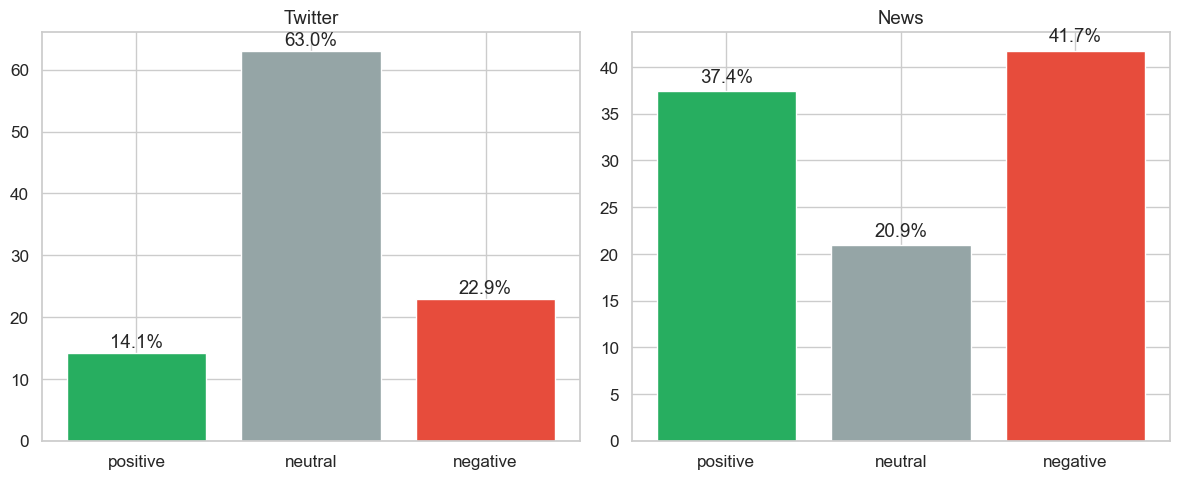

  saved -> outputs/fig2_sentiment_distribution.png


In [31]:
# 12. VISUALISATIONS

sns.set_theme(style="whitegrid", font_scale=1.12)

# --- Figure 2: Sentiment Distribution ---
fig, axes = plt.subplots(1,2,figsize=(12,5))

for ax, (lbl_col, title) in zip(axes, [
    (tweets["pred_label"], "Twitter"),
    (news["news_gold_label"], "News")
]):
    vc = lbl_col.value_counts(normalize=True)*100
    vals = [vc.get(l,0) for l in LABEL_ORDER]

    bars = ax.bar(LABEL_ORDER, vals, color=LABEL_COLS)

    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+1,
                f"{v:.1f}%", ha="center")

    ax.set_title(title)

plt.tight_layout()
plt.show()
savefig(fig, "fig2_sentiment_distribution.png")


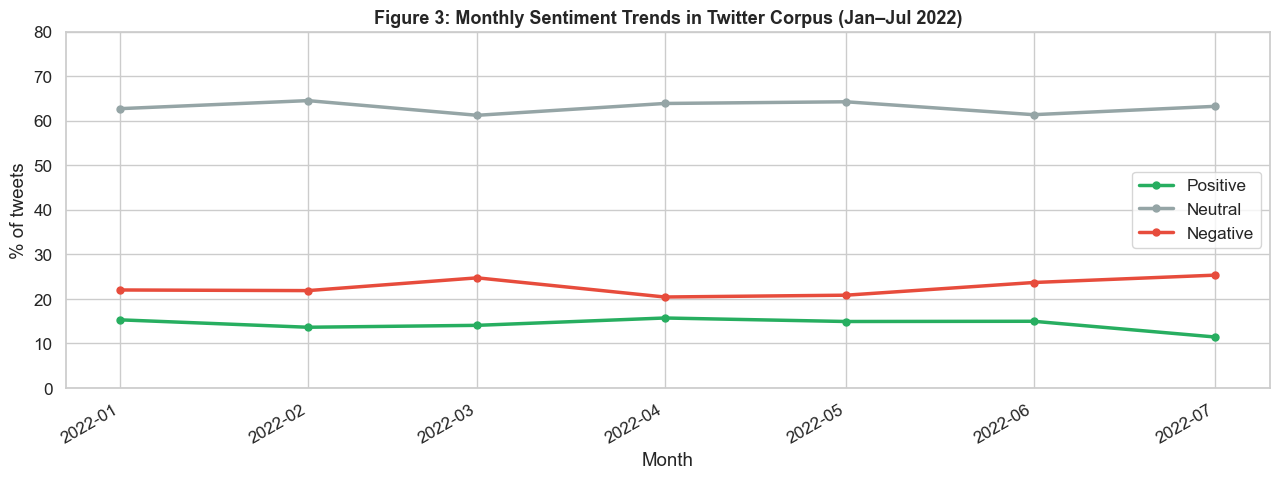

  saved -> outputs/fig3_monthly_trends.png


In [32]:
# Figure 3 – Monthly Trends
tweets["ym"] = tweets["date"].dt.to_period("M")
monthly = tweets.groupby(["ym","pred_label"]).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1),axis=0)*100
monthly_pct.index = monthly_pct.index.to_timestamp()
 
fig, ax = plt.subplots(figsize=(13,5))
for lbl,col in zip(LABEL_ORDER,LABEL_COLS):
    if lbl in monthly_pct.columns:
        ax.plot(monthly_pct.index, monthly_pct[lbl],
                label=lbl.capitalize(), color=col, lw=2.5, marker="o", ms=5)
ax.set_xlabel("Month"); ax.set_ylabel("% of tweets")
ax.set_title("Figure 3: Monthly Sentiment Trends in Twitter Corpus (Jan–Jul 2022)",
             fontsize=13, fontweight="bold")
ax.legend(); ax.set_ylim(0,80)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
savefig(fig, "fig3_monthly_trends.png")
 

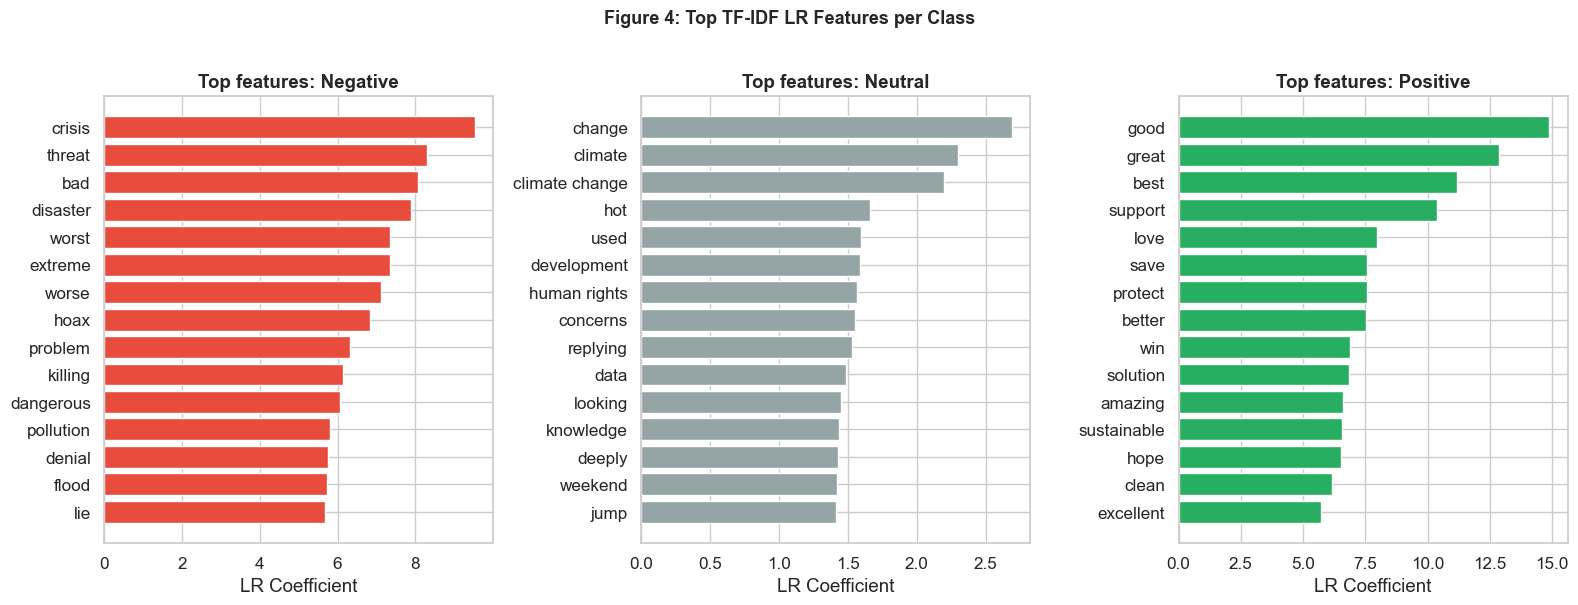

  saved -> outputs/fig4_tfidf_topwords.png


In [33]:
# Figure 4 – Top TF-IDF Features
tfidf_vec     = best_tfidf.named_steps["tfidf"]
clf_lr        = best_tfidf.named_steps["clf"]
feature_names = np.array(tfidf_vec.get_feature_names_out())
classes       = clf_lr.classes_
 
fig, axes = plt.subplots(1,3,figsize=(16,6))
for ax,cls in zip(axes,classes):
    idx   = list(classes).index(cls)
    coefs = clf_lr.coef_[idx]
    top15 = np.argsort(coefs)[-15:][::-1]
    ax.barh(feature_names[top15][::-1], coefs[top15][::-1],
            color=PAL[cls], edgecolor="white")
    ax.set_title(f"Top features: {cls.capitalize()}", fontweight="bold")
    ax.set_xlabel("LR Coefficient")
fig.suptitle("Figure 4: Top TF-IDF LR Features per Class",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
savefig(fig, "fig4_tfidf_topwords.png")

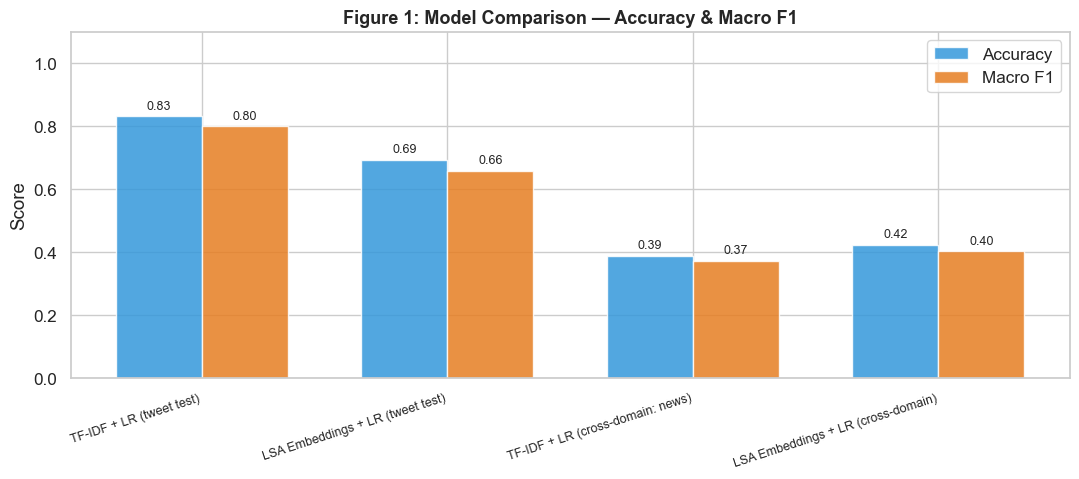

  saved -> outputs/fig1_model_comparison.png


In [ ]:
# Figure 1 – Model Comparison
fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(res_df)); w=0.35
b1 = ax.bar(x-w/2, res_df["Accuracy"], w, label="Accuracy",  color="#3498DB", alpha=0.85)
b2 = ax.bar(x+w/2, res_df["Macro F1"], w, label="Macro F1",  color="#E67E22", alpha=0.85)
ax.bar_label(b1, fmt="%.2f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.2f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(res_df["Model"], rotation=18, ha="right", fontsize=9)
ax.set_ylim(0,1.1); ax.set_ylabel("Score")
ax.set_title("Figure 1: Model Comparison — Accuracy & Macro F1",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()
savefig(fig, "fig1_model_comparison.png")

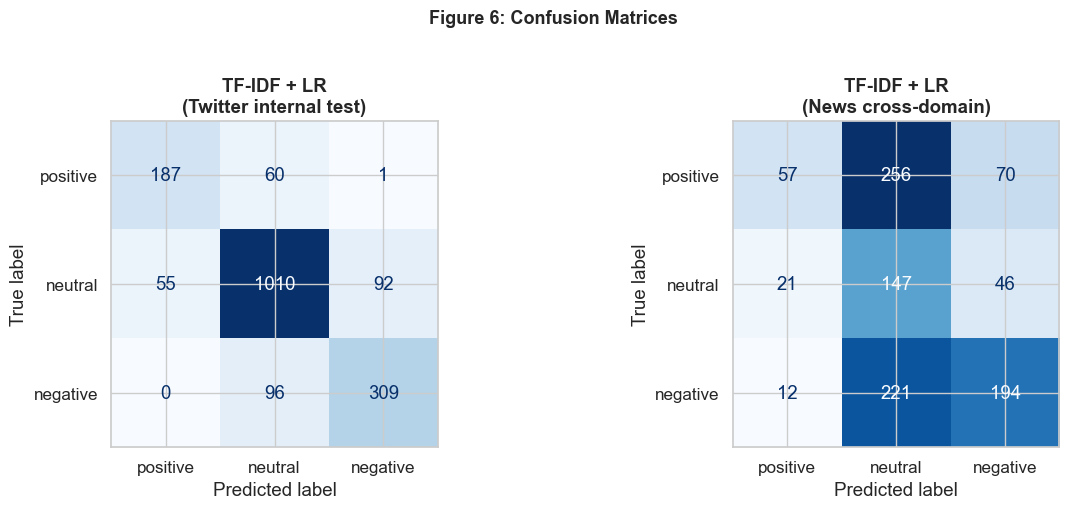

  saved -> outputs/fig6_confusion_matrices.png


In [35]:
# Figure 6 – Confusion Matrices
fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax,(r,title) in zip(axes,[
    (r1,"TF-IDF + LR\n(Twitter internal test)"),
    (r3,"TF-IDF + LR\n(News cross-domain)"),
]):
    cm   = confusion_matrix(r["y_true"],r["y_pred"],labels=LABEL_ORDER)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontweight="bold")
fig.suptitle("Figure 6: Confusion Matrices", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
savefig(fig, "fig6_confusion_matrices.png")
 

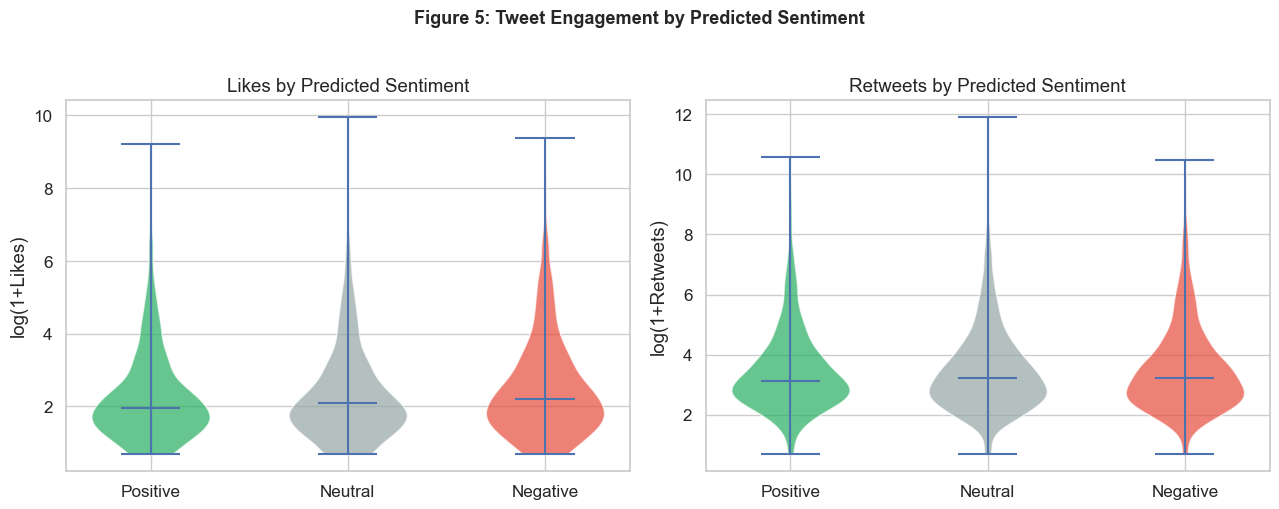

  saved -> outputs/fig5_engagement_vs_sentiment.png


In [34]:
# Figure 5 – Engagement vs Sentiment
fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax,(metric,label) in zip(axes,[("likes_n","Likes"),("retweets_n","Retweets")]):
    data = [tweets[tweets["pred_label"]==l][metric].dropna().apply(np.log1p).values
            for l in LABEL_ORDER]
    parts = ax.violinplot(data, positions=[0,1,2], showmedians=True, widths=0.6)
    for i,(pc,col) in enumerate(zip(parts["bodies"],LABEL_COLS)):
        pc.set_facecolor(col); pc.set_alpha(0.7)
    ax.set_xticks([0,1,2])
    ax.set_xticklabels(["Positive","Neutral","Negative"])
    ax.set_ylabel(f"log(1+{label})")
    ax.set_title(f"{label} by Predicted Sentiment")
fig.suptitle("Figure 5: Tweet Engagement by Predicted Sentiment",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
savefig(fig, "fig5_engagement_vs_sentiment.png")

In [21]:
# 13. STATISTICAL ANALYSIS
print("\n"+"="*60)
print("STATISTICAL ANALYSIS")
print("="*60)
 
u, p = mannwhitneyu(tweets["afinn_score"].values,
                    news["afinn_score"].values, alternative="two-sided")
print(f"\nMann-Whitney U (Twitter vs News AFINN scores):")
print(f"  U={u:.1f}, p={p:.4e}")
print("  ->", "Significant (p<0.05)" if p<0.05 else "Not significant")
 
valid = tweets[["afinn_score","likes_n"]].dropna()
rho, pr = spearmanr(valid["afinn_score"], valid["likes_n"])
print(f"\nSpearman r (AFINN score vs Likes): rho={rho:.3f}, p={pr:.4e}")
 
print("\nFinal results table:")
print(res_df.to_string(index=False))
print("\nDone. All outputs in outputs/")


STATISTICAL ANALYSIS

Mann-Whitney U (Twitter vs News AFINN scores):
  U=5155580.5, p=7.6298e-10
  -> Significant (p<0.05)

Spearman r (AFINN score vs Likes): rho=-0.057, p=1.3292e-07

Final results table:
                             Model  Accuracy  Macro F1  Domain
          TF-IDF + LR (tweet test)  0.832044  0.799543 Twitter
  LSA Embeddings + LR (tweet test)  0.693370  0.658210 Twitter
  TF-IDF + LR (cross-domain: news)  0.388672  0.372770    News
LSA Embeddings + LR (cross-domain)  0.423828  0.402915    News

Done. All outputs in outputs/
